Using grouped cross-validation based on cell–temperature combinations, the stacked ensemble improved predictive performance (R² = 0.905) compared to the best single model (Random Forest, R² = 0.896). The positive linear meta-learner assigned dominant weights to Random Forest (57%) and LightGBM (40%), indicating complementary predictive behavior between bagging and gradient boosting approaches.

In [92]:
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.base import clone
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
    }


In [ ]:

# Load the merged dataset
df = pd.read_csv('/Users/yaswanthkanagarla/Desktop/Master_Thesis/BD_code/Battery_Diagnostics_Thesis/scripts/merged_eis_capacity_state_IX_norm.csv')

# Convert 'state' if needed
state_map = {'I': 1, 'II': 2, 'III': 3, 'IV': 4, 'V': 5, 'VI': 6, 'VII': 7, 'VIII': 8, 'IX': 9}
df['state'] = df['state'].map(state_map)
train_groups = [(25, 6), (25, 7), (25, 8), (25, 5), (25, 3), (25, 4), (35, 1), (25, 2), (45, 2)]
test_groups  = [(25, 1), (35, 2), (45, 1)]         # final test cell(s)

In [ ]:
def mask_from_groups(df, groups):
    groups = set(groups)
    return df.apply(lambda r: (r["T_C"], r["cell"]) in groups, axis=1)

train_mask = mask_from_groups(df, train_groups)
test_mask  = mask_from_groups(df, test_groups)

train_df = df[train_mask].copy()
test_df  = df[test_mask].copy()

print("Train:", train_df.shape, "Groups:", sorted(set(zip(train_df.T_C, train_df.cell))))
print("Test :", test_df.shape,  "Groups:", sorted(set(zip(test_df.T_C, test_df.cell))))

Train: (1770, 31) Groups: [(25, 2), (25, 3), (25, 4), (25, 5), (25, 6), (25, 7), (25, 8), (35, 1), (45, 2)]
Test : (966, 31) Groups: [(25, 1), (35, 2), (45, 1)]


In [ ]:
for X in (X_train, X_test):
    X.replace([np.inf, -np.inf], np.nan, inplace=True)

# If you have any NaNs after this, RF will fail.
# Either drop or impute. Impute is better:
from sklearn.impute import SimpleImputer

imp = SimpleImputer(strategy="median")
X_train[:] = imp.fit_transform(X_train)
X_test[:]  = imp.transform(X_test)


features = [
    "R_s_rel",
    "R_ct_rel",
    "R_sei_rel",
    "Zmag_0.1Hz_rel",
    "C_dl_log",
    "tail_slope","Zmag_1000Hz_rel",
    "T_C"
]

X_train, y_train = train_df[features], train_df["SOH"]
#X_val,   y_val   = val_df[features],   val_df["SOH"]
X_test,  y_test  = test_df[features],  test_df["SOH"]

print("NaNs train:", X_train.isna().sum().sum(), '"val:", X_val.isna().sum().sum(),' "test:", X_test.isna().sum().sum())


NaNs train: 0 "val:", X_val.isna().sum().sum(),test: 0


Random forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_base = RandomForestRegressor(
    n_estimators=600,
    random_state=42,
    n_jobs=-1,
    max_features="sqrt",
    min_samples_leaf=1
)

rf_base.fit(X_train, y_train)
rf_base.fit(X_train, y_train)
print("RF TEST:", metrics(y_test, rf_base.predict(X_test)))

print("Base RF")
#print("Train:", metrics(y_train, rf_base.predict(X_train)))
#print("Test :", metrics(y_test,  rf_base.predict(X_test)))

RF TEST: {'R2': 0.8955195004457781, 'MAE': 0.04853078421423649, 'RMSE': np.float64(0.05868915338290508)}
Base RF


XgBoost

In [73]:
import numpy as np
from xgboost import XGBRegressor



xgb_stack = XGBRegressor(
    n_estimators=8000,
    learning_rate=0.08,
    max_depth=3,
    subsample=1.0,
    colsample_bytree=0.7,
    reg_lambda=0.5,
    random_state=42,
    n_jobs=-1,
    objective="reg:squarederror",
    eval_metric="rmse"
    # NOTE: no early_stopping_rounds here
)
xgb_stack.fit(X_train, y_train)
print("XGB TEST:", metrics(y_test, xgb_stack.predict(X_test)))




XGB TEST: {'R2': 0.8696147884407313, 'MAE': 0.04972599613031385, 'RMSE': np.float64(0.06556233196569602)}


LightGBM

In [121]:
import lightgbm as lgb

force_col_wise=True

lgbm = lgb.LGBMRegressor(
    n_estimators=5000,
    learning_rate=0.05,
    num_leaves=15,
    max_depth=-1,          # -1 = no limit
    subsample=0.7,
    colsample_bytree=0.7,
    reg_lambda=1.0,
    min_child_samples=50,
    random_state=42,
    n_jobs=-1,
    #force_col_wise=true
)
lgbm.fit(X_train, y_train)
print("LGBM TEST:", metrics(y_test, lgbm.predict(X_test)))



[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000338 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1789
[LightGBM] [Info] Number of data points in the train set: 1770, number of used features: 8
[LightGBM] [Info] Start training from score 0.730683
LGBM TEST: {'R2': 0.8539953426742571, 'MAE': 0.04881568730676375, 'RMSE': np.float64(0.06937828804233398), 'MSE': 0.0048133468516850615}


CatBoost

In [75]:
from catboost import CatBoostRegressor

cat = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    verbose=0,
    random_seed=42
)

cat.fit(X_train, y_train)

print("Train:", metrics(y_train, cat.predict(X_train)))
#print("Val  :", metrics(y_val,   cat.predict(X_val)))
print("Test :", metrics(y_test,  cat.predict(X_test)))

Train: {'R2': 0.9991527766893136, 'MAE': 0.003914270672870622, 'RMSE': np.float64(0.00517756591891994)}
Test : {'R2': 0.889995898175617, 'MAE': 0.04509748708282488, 'RMSE': np.float64(0.060220542581881045)}


In [76]:
base_models = {
    "rf": rf_base,
    "xgb": xgb_stack,
    "lgb": lgbm,
    "cb": cat
}


groupkfold

In [77]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.base import clone

def get_oof_predictions_group(models, X, y, X_test, groups, n_splits=5):
    gkf = GroupKFold(n_splits=n_splits)

    oof_train = pd.DataFrame(index=X.index)
    oof_test  = pd.DataFrame(index=X_test.index)

    for name, model in models.items():
        oof_pred = np.zeros(len(X))
        test_pred_folds = np.zeros((len(X_test), n_splits))

        for fold, (tr_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
            X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

            m = clone(model)
            m.fit(X_tr, y_tr)

            oof_pred[val_idx] = m.predict(X_val)
            test_pred_folds[:, fold] = m.predict(X_test)

        oof_train[name] = oof_pred
        oof_test[name]  = test_pred_folds.mean(axis=1)

        print(f"{name} GROUP-OOF metrics:", metrics(y, oof_train[name].values))

    return oof_train, oof_test
# 1) Build groups using (cell, T_C) combo
groups = df.loc[X_train.index, ["cell", "T_C"]].astype(str).agg("_".join, axis=1)

# 2) Keep T_C as feature, but DROP cell from features
X_train_feat = X_train.drop(columns=["cell"]) if "cell" in X_train.columns else X_train
X_test_feat  = X_test.drop(columns=["cell"])  if "cell" in X_test.columns else X_test


oof_train, oof_test = get_oof_predictions_group(
    base_models, X_train_feat, y_train, X_test_feat,
    groups=groups, n_splits=5
)




rf GROUP-OOF metrics: {'R2': 0.5222224716342957, 'MAE': 0.08662381264750428, 'RMSE': np.float64(0.12295311848909861)}
xgb GROUP-OOF metrics: {'R2': 0.4542761871070763, 'MAE': 0.09871427675478381, 'RMSE': np.float64(0.13140537835113064)}
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000158 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1789
[LightGBM] [Info] Number of data points in the train set: 1443, number of used features: 8
[LightGBM] [Info] Start training from score 0.768284
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000198 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1788
[LightGBM] [Info] Number of data points in the train set: 1409, number of used features: 8
[LightGBM] [Info] Start training from score 0.724022
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing w

meta model- Linear Regreesion

In [78]:
from sklearn.linear_model import LinearRegression

meta_pos = LinearRegression(positive=True)
meta_pos.fit(oof_train, y_train)
stack_pred = meta_pos.predict(oof_test)

print("Stack (positive LR):", metrics(y_test, stack_pred))
print(pd.Series(meta_pos.coef_, index=oof_train.columns))


Stack (positive LR): {'R2': 0.9049656347633585, 'MAE': 0.0462067287086196, 'RMSE': np.float64(0.05597325506696246)}
rf     0.573038
xgb    0.055085
lgb    0.401513
cb     0.000000
dtype: float64


/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_nnls.py:164: RuntimeWarning: divide by zero encountered in matmul
  return x, np.linalg.norm(A@x - b), 1
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_nnls.py:164: RuntimeWarning: overflow encountered in matmul
  return x, np.linalg.norm(A@x - b), 1
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_nnls.py:164: RuntimeWarning: invalid value encountered in matmul
  return x, np.linalg.norm(A@x - b), 1
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/

In [79]:
meta_model = Ridge(alpha=1.0, random_state=42)
meta_model.fit(oof_train, y_train)

stack_pred = meta_model.predict(oof_test)
print("STACKED TEST:", metrics(y_test, stack_pred))


STACKED TEST: {'R2': 0.903198594364454, 'MAE': 0.04508821462888919, 'RMSE': np.float64(0.05649123330700586)}


/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [80]:
# Fit each base model on full train and evaluate on test
for name, model in base_models.items():
    m = clone(model)
    m.fit(X_train_feat, y_train)
    pred = m.predict(X_test_feat)
    print(name, "TEST:", metrics(y_test, pred))


rf TEST: {'R2': 0.8955195004457781, 'MAE': 0.0485307842142365, 'RMSE': np.float64(0.05868915338290508)}
xgb TEST: {'R2': 0.8696147884407313, 'MAE': 0.04972599613031385, 'RMSE': np.float64(0.06556233196569602)}
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000190 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1789
[LightGBM] [Info] Number of data points in the train set: 1770, number of used features: 8
[LightGBM] [Info] Start training from score 0.730683
lgb TEST: {'R2': 0.8539953426742571, 'MAE': 0.04881568730676375, 'RMSE': np.float64(0.06937828804233398)}
cb TEST: {'R2': 0.889995898175617, 'MAE': 0.04509748708282488, 'RMSE': np.float64(0.060220542581881045)}


confidence interval

In [81]:
import numpy as np

def bootstrap_ci(y_true, y_pred, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    scores = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        score = r2_score(y_true.iloc[idx], y_pred[idx])
        scores.append(score)

    lower = np.percentile(scores, 2.5)
    upper = np.percentile(scores, 97.5)
    return np.mean(scores), lower, upper

mean_r2, low, high = bootstrap_ci(y_test, stack_pred)

print(f"Stack R² mean: {mean_r2:.4f}")
print(f"95% CI: [{low:.4f}, {high:.4f}]")


Stack R² mean: 0.9028
95% CI: [0.8878, 0.9148]


In [83]:
from sklearn.base import clone

test_preds = {}

for name, model in base_models.items():
    m = clone(model)
    m.fit(X_train_feat, y_train)
    test_preds[name] = m.predict(X_test_feat)

print("Saved predictions for:", list(test_preds.keys()))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000172 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1789
[LightGBM] [Info] Number of data points in the train set: 1770, number of used features: 8
[LightGBM] [Info] Start training from score 0.730683
Saved predictions for: ['rf', 'xgb', 'lgb', 'cb']


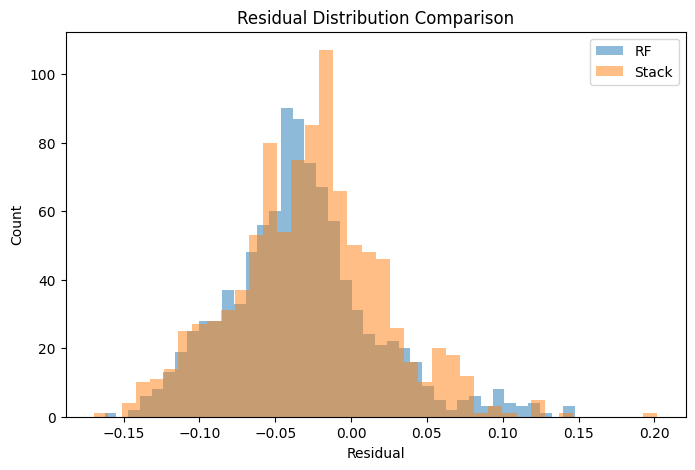

In [84]:
import matplotlib.pyplot as plt

rf_pred = test_preds["rf"]

rf_res = y_test - rf_pred
stack_res = y_test - stack_pred

plt.figure(figsize=(8,5))
plt.hist(rf_res, bins=40, alpha=0.5, label="RF")
plt.hist(stack_res, bins=40, alpha=0.5, label="Stack")
plt.legend()
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("Residual Distribution Comparison")
plt.show()


In [85]:
import pandas as pd

results_table = pd.DataFrame({
    "Model": ["RF", "XGB", "LGB", "CB", "Stack"],
    "R2": [
        0.8955,
        0.8696,
        0.8540,
        0.8900,
        0.9050
    ]
})

results_table.sort_values("R2", ascending=False)


,Model,R2
4,Stack,0.9050
0,RF,0.8955
3,CB,0.8900
1,XGB,0.8696
2,LGB,0.8540


/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


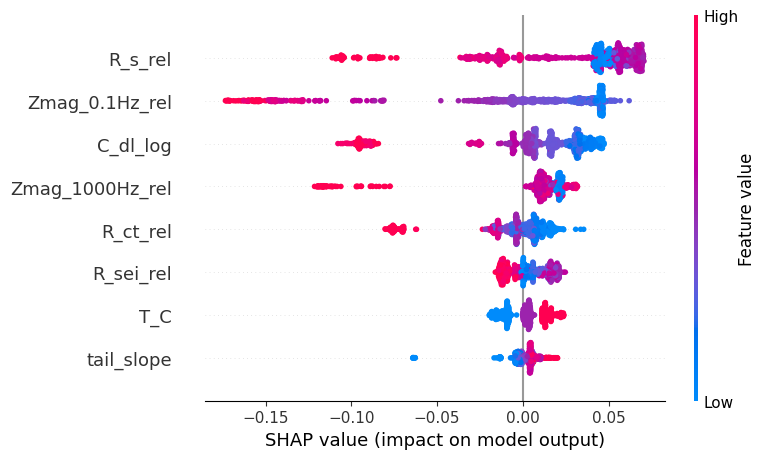

In [86]:
import shap

explainer = shap.TreeExplainer(rf_base)
shap_values = explainer.shap_values(X_test_feat)

shap.summary_plot(shap_values, X_test_feat)


In [87]:
meta_shap = meta_pos.coef_
print(pd.Series(meta_shap, index=oof_train.columns))


rf     0.573038
xgb    0.055085
lgb    0.401513
cb     0.000000
dtype: float64


In [89]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.base import clone
import numpy as np

# --- Define X and y properly ---
feature_cols = [c for c in df.columns if c not in ["SOH", "cell"]]
X_full = df[feature_cols]
y_full = df["SOH"]

# --- Build groups (cell + temperature combo) ---
groups_full = df[["cell", "T_C"]].astype(str).agg("_".join, axis=1)

gss = GroupShuffleSplit(n_splits=5, test_size=0.3, random_state=42)

all_scores = []

for train_idx, test_idx in gss.split(X_full, y_full, groups=groups_full):

    X_tr, X_te = X_full.iloc[train_idx], X_full.iloc[test_idx]
    y_tr, y_te = y_full.iloc[train_idx], y_full.iloc[test_idx]

    m = clone(rf_base)  # or try stacking later
    m.fit(X_tr, y_tr)
    pred = m.predict(X_te)

    score = r2_score(y_te, pred)
    all_scores.append(score)

print("Mean R²:", np.mean(all_scores))
print("Std R² :", np.std(all_scores))


Mean R²: 0.6907343988880058
Std R² : 0.19961898306878306


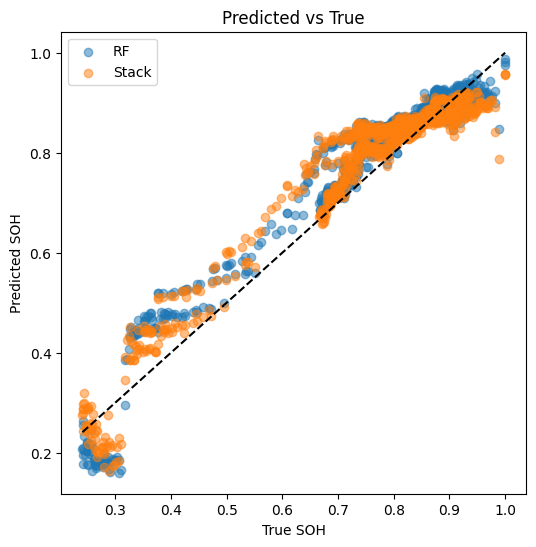

In [91]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, test_preds["rf"], alpha=0.5, label="RF")
plt.scatter(y_test, stack_pred, alpha=0.5, label="Stack")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'k--')

plt.xlabel("True SOH")
plt.ylabel("Predicted SOH")
plt.legend()
plt.title("Predicted vs True")
plt.show()


In [96]:
cv_preds = {}

# from previous CV evaluation loop
for name in base_models.keys():
    cv_preds[name] = oof_train[name].values


In [109]:
from sklearn.metrics import r2_score

def plot_pred_vs_true(y_true, y_pred, title):
    r2 = r2_score(y_true, y_pred)
    
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.5)
    
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    
    plt.plot([min_val, max_val],
             [min_val, max_val],
             'k--', linewidth=1)
    
    plt.xlabel("True SOH")
    plt.ylabel("Predicted SOH")
    plt.title(f"{title}\nR² = {r2:.3f}")
    plt.tight_layout()
    plt.show()



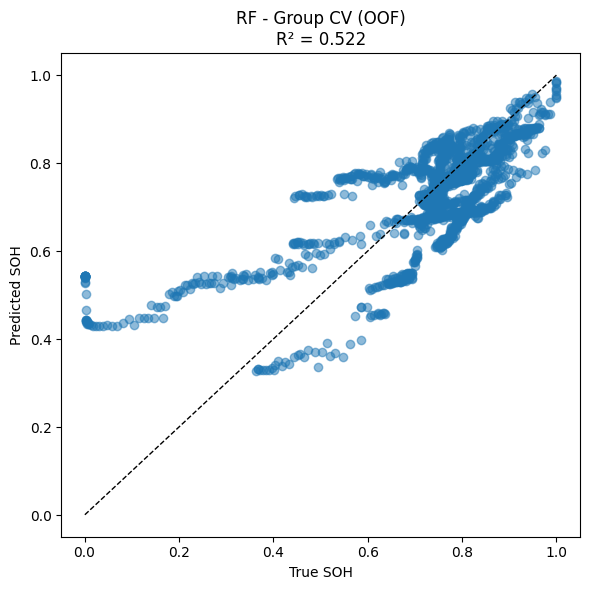

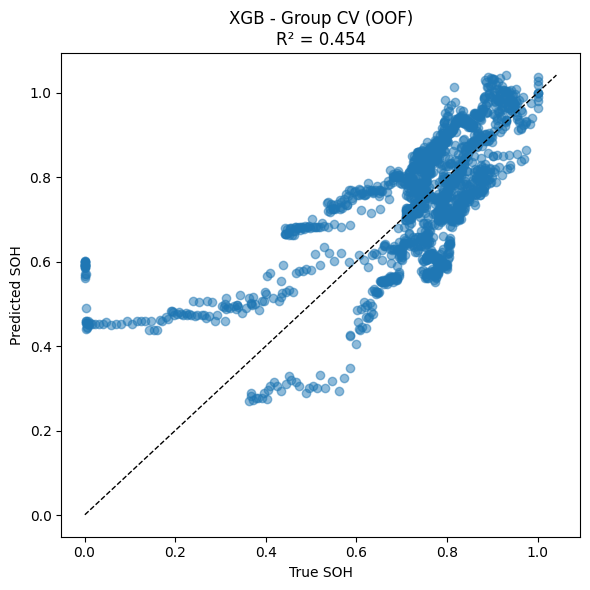

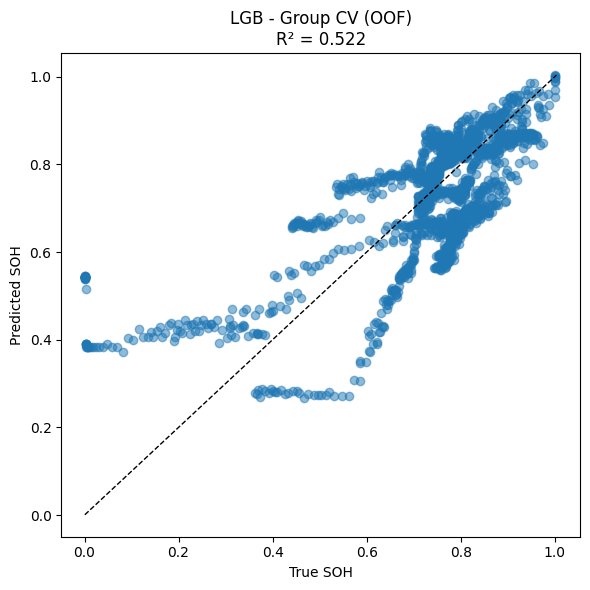

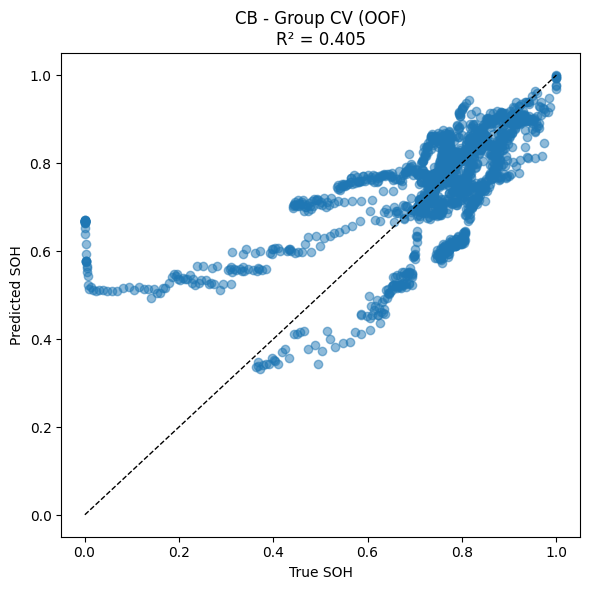

In [110]:
for name in base_models.keys():
    plot_pred_vs_true(
        y_train,
        cv_preds[name],
        title=f"{name.upper()} - Group CV (OOF)"
    )


In [111]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.base import clone
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MSE": mean_squared_error(y_true, y_pred),
    }

# --- Build groups for TRAIN only (cell + temp combo) ---
groups_train = df.loc[X_train.index, ["cell", "T_C"]].astype(str).agg("_".join, axis=1)

# --- Use features (drop cell ID if it exists in X matrices) ---
X_train_feat = X_train.drop(columns=["cell"]) if "cell" in X_train.columns else X_train
X_test_feat  = X_test.drop(columns=["cell"])  if "cell" in X_test.columns else X_test


def evaluate_model_groupcv_and_test(model, X_train, y_train, groups_train, X_test, y_test, n_splits=5):
    # safety: must not ask for more folds than groups
    n_splits = min(n_splits, pd.Series(groups_train).nunique())
    gkf = GroupKFold(n_splits=n_splits)

    oof_pred = np.zeros(len(X_train))

    # --- GroupCV (validation) on TRAIN only ---
    for tr_idx, val_idx in gkf.split(X_train, y_train, groups=groups_train):
        m = clone(model)
        m.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
        oof_pred[val_idx] = m.predict(X_train.iloc[val_idx])

    cv_scores = metrics(y_train, oof_pred)

    # --- Final model trained on ALL TRAIN, evaluated on TEST ---
    m_full = clone(model)
    m_full.fit(X_train, y_train)
    test_pred = m_full.predict(X_test)

    test_scores = metrics(y_test, test_pred)

    return cv_scores, test_scores, test_pred


In [112]:
results = []
test_preds_single = {}

for name, model in base_models.items():
    cv_scores, test_scores, test_pred = evaluate_model_groupcv_and_test(
        model,
        X_train_feat, y_train,
        groups_train,
        X_test_feat, y_test,
        n_splits=5
    )

    results.append({
        "model": name,
        "CV_R2": cv_scores["R2"],
        "CV_RMSE": cv_scores["RMSE"],
        "CV_MAE": cv_scores["MAE"],
        "TEST_R2": test_scores["R2"],
        "TEST_RMSE": test_scores["RMSE"],
        "TEST_MAE": test_scores["MAE"],
    })

    test_preds_single[name] = test_pred

results_df = pd.DataFrame(results).sort_values("TEST_R2", ascending=False)
results_df


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000181 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1789
[LightGBM] [Info] Number of data points in the train set: 1443, number of used features: 8
[LightGBM] [Info] Start training from score 0.768284
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000172 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1788
[LightGBM] [Info] Number of data points in the train set: 1409, number of used features: 8
[LightGBM] [Info] Start training from score 0.724022
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000171 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1788
[LightGBM] [Info] Number of data points in the train set: 1423, number of used features: 8
[LightGBM] [Info] Start training 

,model,CV_R2,CV_RMSE,CV_MAE,TEST_R2,TEST_RMSE,TEST_MAE
0,rf,0.522222,0.122953,0.086624,0.895520,0.058689,0.048531
3,cb,0.404940,0.137217,0.088399,0.889996,0.060221,0.045097
1,xgb,0.454276,0.131405,0.098714,0.869615,0.065562,0.049726
2,lgb,0.521976,0.122985,0.091174,0.853995,0.069378,0.048816


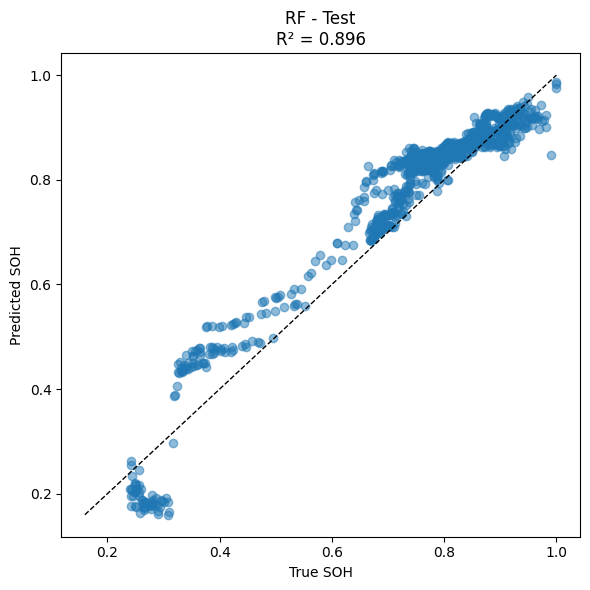

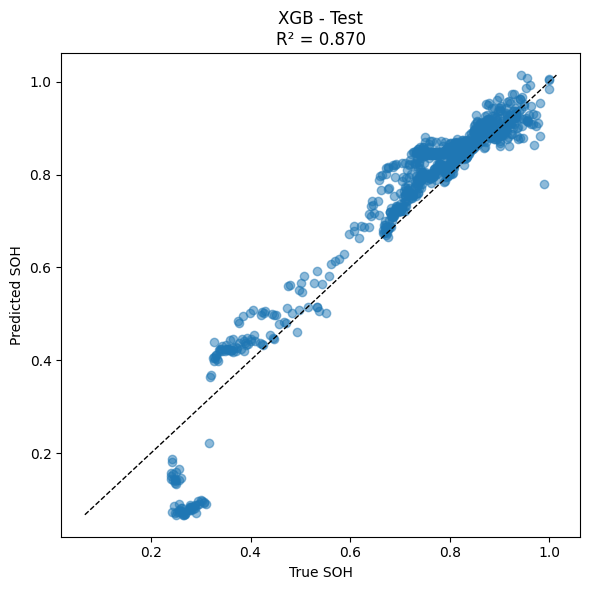

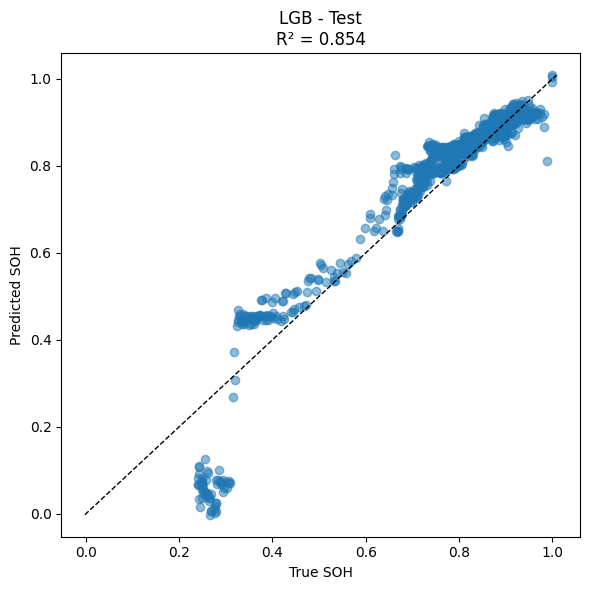

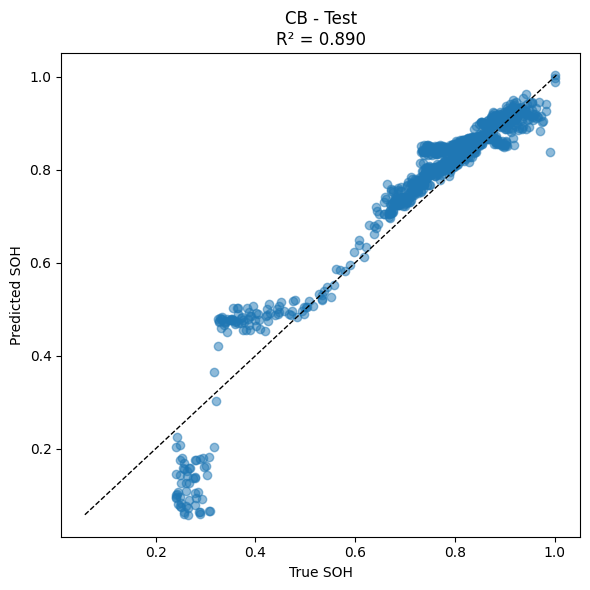

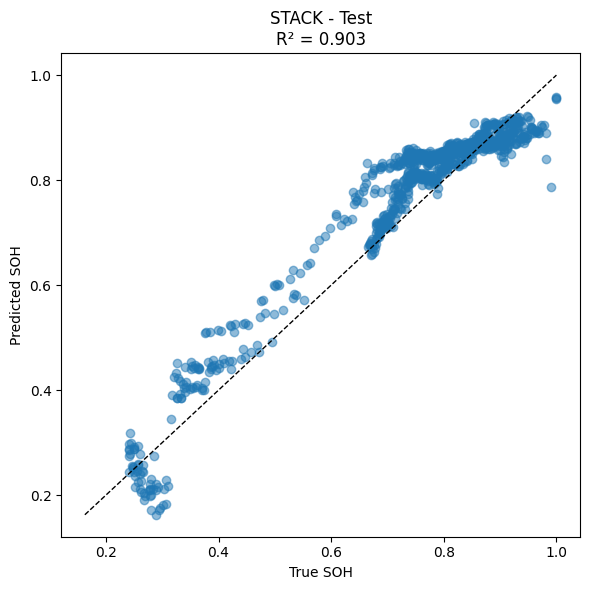

In [113]:
# Base models
for name in base_models.keys():
    plot_pred_vs_true(
        y_test,
        test_preds_single[name],
        title=f"{name.upper()} - Test"
    )

# Stack
plot_pred_vs_true(
    y_test,
    stack_pred,
    title="STACK - Test"
)


In [114]:
from sklearn.base import clone

train_preds_single = {}

for name, model in base_models.items():
    m = clone(model)
    m.fit(X_train_feat, y_train)
    train_preds_single[name] = m.predict(X_train_feat)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000160 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1789
[LightGBM] [Info] Number of data points in the train set: 1770, number of used features: 8
[LightGBM] [Info] Start training from score 0.730683


In [115]:
# stacking train prediction
meta_model.fit(oof_train, y_train)
stack_train_pred = meta_model.predict(oof_train)


/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [118]:
import matplotlib.pyplot as plt

def plot_all_sets(y_train, y_train_pred,
                  y_cv_pred,
                  y_test, y_test_pred,
                  title):

    plt.figure(figsize=(6,6))

    # Train
    plt.scatter(y_train, y_train_pred, alpha=0.3, label="Train")

    # CV (OOF) only if provided
    if y_cv_pred is not None:
        plt.scatter(y_train, y_cv_pred, alpha=0.5, label="Group-CV")

    # Test
    plt.scatter(y_test, y_test_pred, alpha=0.7, label="Test")

    # Diagonal reference line
    min_val = min(y_train.min(), y_test.min())
    max_val = max(y_train.max(), y_test.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1)

    plt.xlabel("True SOH")
    plt.ylabel("Predicted SOH")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [119]:
stack_cv_pred = meta_model.predict(oof_train)


/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


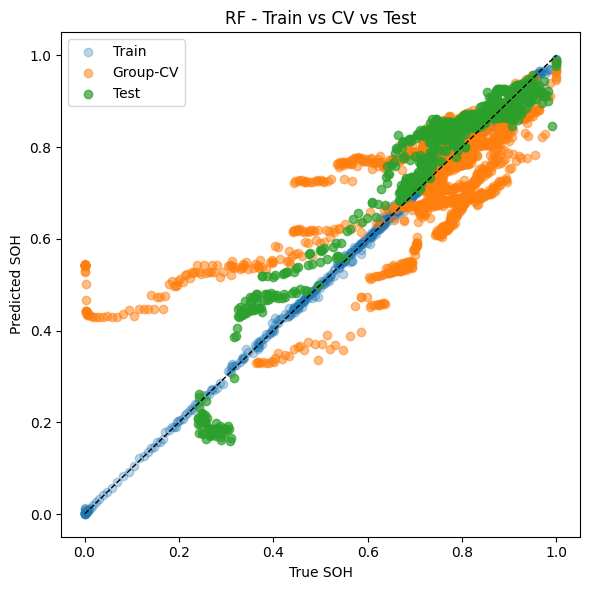

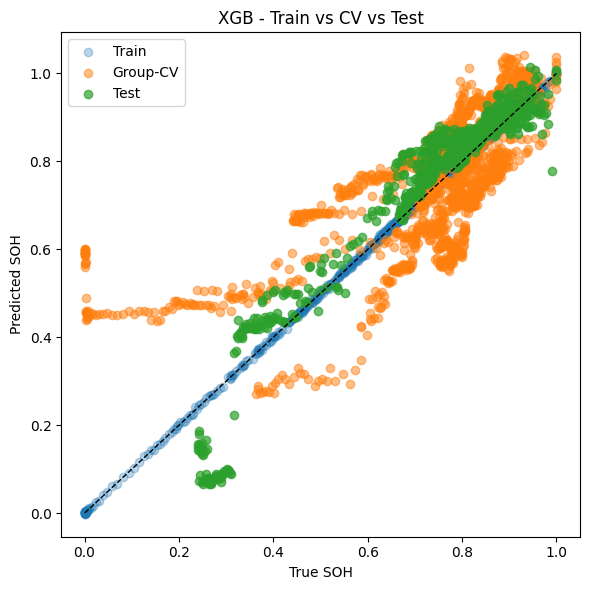

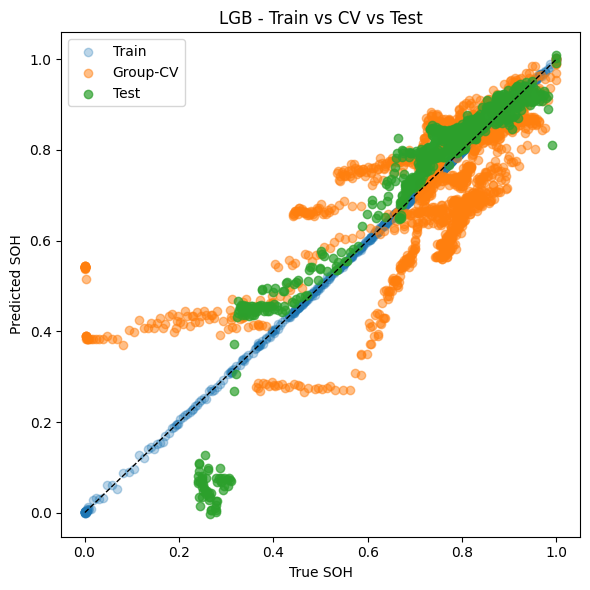

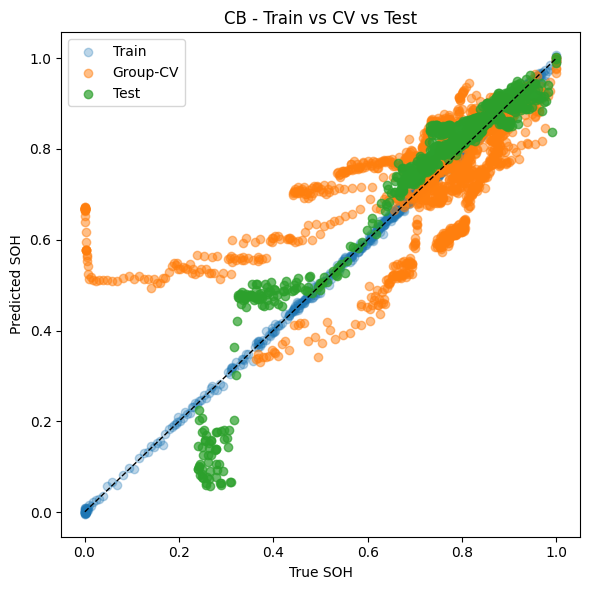

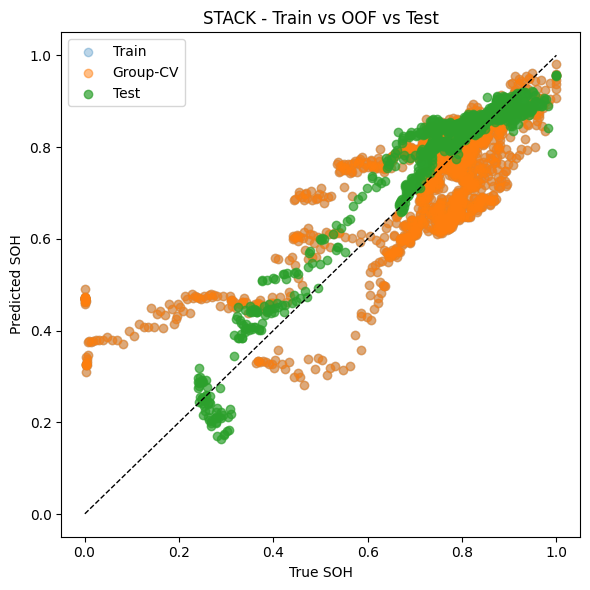

In [120]:
for name in base_models.keys():
    plot_all_sets(
        y_train,
        train_preds_single[name],
        cv_preds[name],
        y_test,
        test_preds_single[name],
        title=f"{name.upper()} - Train vs CV vs Test"
    )


plot_all_sets(
    y_train,
    stack_train_pred,
    stack_cv_pred,
    y_test,
    stack_pred,
    title="STACK - Train vs OOF vs Test"
)

